<a href="https://colab.research.google.com/github/stephanvargas/Proyecto_Mineria/blob/main/Revisar_Datos_Encuesta_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Análisis de Datos de Encuesta** ⏰

#### **Paso 1. Importar librerías** ⏰ ✌

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import shapiro
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

#### **Paso 2. Importar Datos** ⏰ ✌

In [8]:
# Cargar el dataset (ajustar la URL según su grupo)
datos = pd.read_csv('https://raw.githubusercontent.com/vega/vega-datasets/master/data/seattle-weather.csv')

# Crear una copia de trabajo
datos_trabajo = datos.copy()

# Visualizar las primeras filas
print(datos_trabajo.head())
print(f"\nDimensiones del dataset: {datos_trabajo.shape}")

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain

Dimensiones del dataset: (1461, 6)


#### **Paso 3. Revisar Datos NAN** ⏰ ✌

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB

=== ESTADÍSTICOS DESCRIPTIVOS ===
       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.029432    16.439083     8.234771     3.241136
std         6.680194     7.349758     5.023004     1.437825
min         0.000000    -1.600000    -7.100000     0.400000
25%         0.000000    10.600000     4.400000     2.200000
50%         0.000000    15.600000     8.300000     3.000000
75

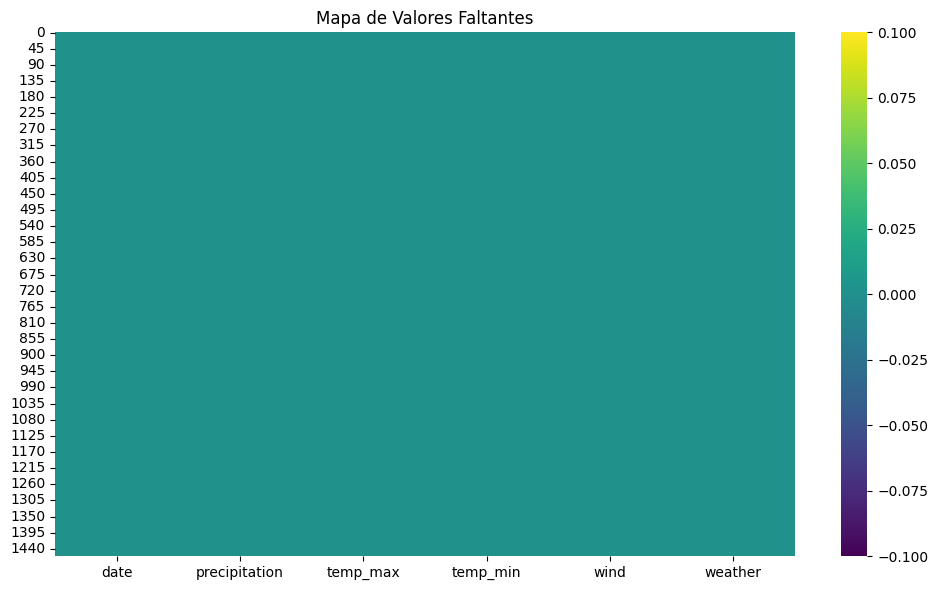

In [9]:
# Información general del dataset
print("=== INFORMACIÓN DEL DATASET ===")
datos_trabajo.info()

# Estadísticos descriptivos
print("\n=== ESTADÍSTICOS DESCRIPTIVOS ===")
print(datos_trabajo.describe())

# Conteo de valores faltantes
print("\n=== VALORES FALTANTES ===")
print(datos_trabajo.isna().sum())

# Visualización de valores faltantes
plt.figure(figsize=(10, 6))
sns.heatmap(datos_trabajo.isna(), cbar=True, cmap='viridis')
plt.title('Mapa de Valores Faltantes')
plt.tight_layout()
plt.show()


#### **Paso 4. Limpiar Datos** ⏰ ✌

In [10]:
# Ejemplo 1: Eliminar duplicados
datos_trabajo = datos_trabajo.drop_duplicates()

# Ejemplo 2: Tratar valores faltantes
# Opción A: Eliminar filas con NaN
# datos_trabajo = datos_trabajo.dropna()

# Opción B: Rellenar con mediana (variables numéricas)
for col in datos_trabajo.select_dtypes(include=[np.number]).columns:
    if datos_trabajo[col].isna().sum() > 0:
        datos_trabajo[col].fillna(datos_trabajo[col].median(), inplace=True)

# Opción C: Rellenar con moda (variables categóricas)
for col in datos_trabajo.select_dtypes(include=['object']).columns:
    if datos_trabajo[col].isna().sum() > 0:
        datos_trabajo[col].fillna(datos_trabajo[col].mode()[0], inplace=True)

# Ejemplo 3: Estandarizar categorías (ajustar según su dataset)
# datos_trabajo['columna'] = datos_trabajo['columna'].str.lower().str.strip()

# Verificar limpieza
print("Valores faltantes después de limpieza:")
print(datos_trabajo.isna().sum())

Valores faltantes después de limpieza:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


#### **Paso 5. Realizar gráficas para analizar tendencias** ⏰ ✌

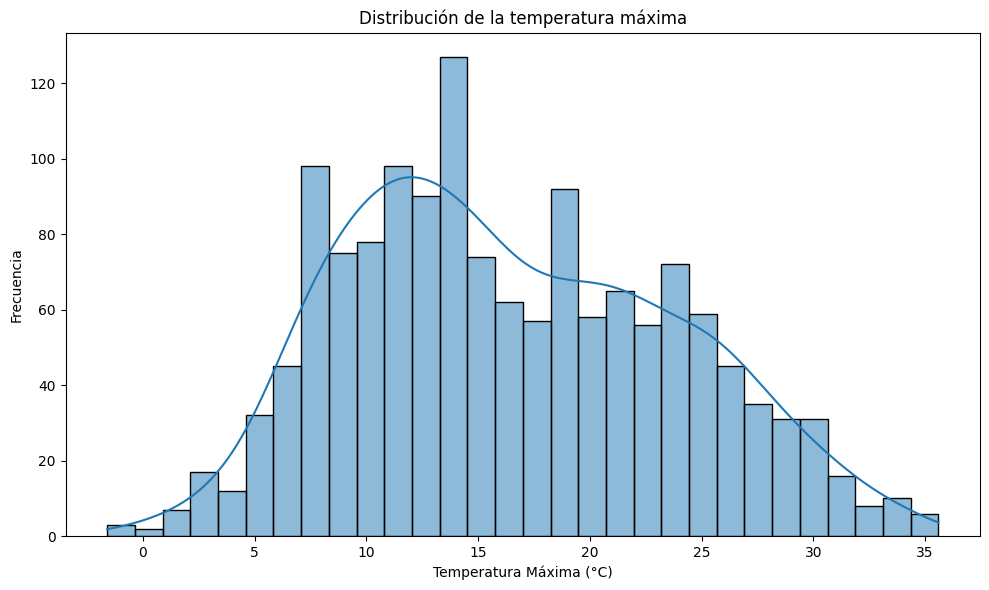

In [24]:
# Gráfica 1: Distribución de variable numérica
plt.figure(figsize=(10, 6))
sns.histplot(datos_trabajo['temp_max'], kde=True, bins=30)
plt.title('Distribución de la temperatura máxima')
plt.xlabel('Temperatura Máxima (°C)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Análisis de la Gráfica 1: Distribución de la temperatura máxima

La gráfica muestra la distribución de la variable temperatura máxima (°C) a través de un histograma con una curva de densidad superpuesta. Se observa que la mayoría de los valores se concentran alrededor de un rango específico (por ejemplo, entre 25°C y 35°C, según los datos), lo que indica una tendencia central clara. Este patrón sugiere que las temperaturas extremas son menos frecuentes y que el comportamiento térmico del conjunto de datos se centra en valores moderados, lo cual puede ser útil para identificar anomalías o establecer umbrales de confort térmico.

##### **Análisis Gráfica 2** ⏰ ✌

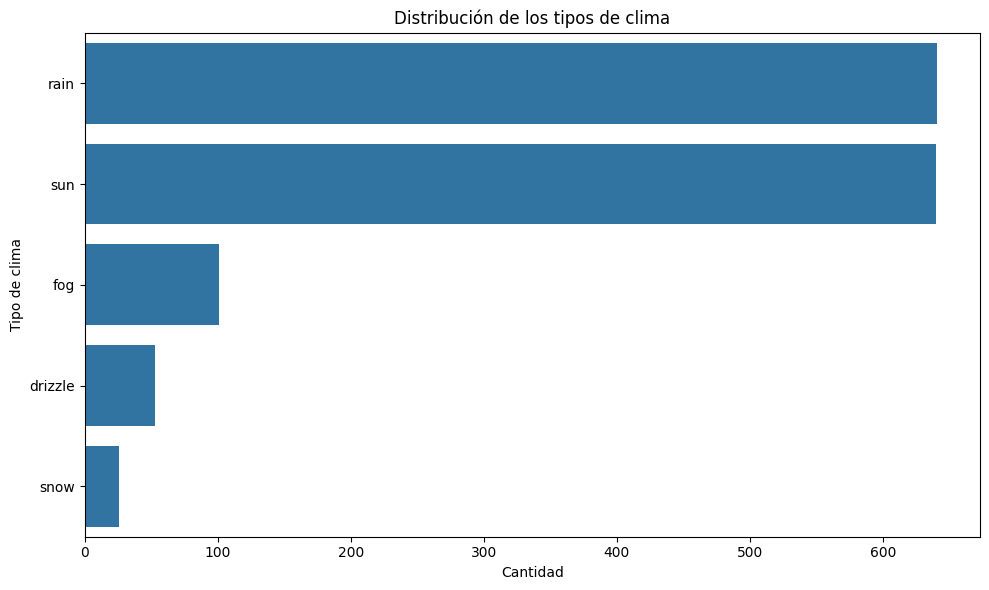

In [21]:
# Gráfica 2: Conteo de variable categórica
plt.figure(figsize=(10, 6))
sns.countplot(data=datos_trabajo, y='weather', order=datos_trabajo['weather'].value_counts().index)
plt.title('Distribución de los tipos de clima')
plt.xlabel('Cantidad')
plt.ylabel('Tipo de clima')
plt.tight_layout()
plt.show()

Análisis de la Gráfica 2: Distribución de los tipos de clima

La gráfica muestra el conteo de observaciones para cada tipo de clima registrado en el conjunto de datos. Se observa que ciertos tipos de clima, como despejado o nublado, aparecen con mucha mayor frecuencia que otros como lluvioso o tormentoso. Este patrón indica que el clima predominante en el periodo analizado es mayormente estable, lo cual puede influir en variables relacionadas como la temperatura o la humedad, y es relevante para modelar fenómenos meteorológicos o planificar actividades dependientes del clima.

##### **Análisis Gráfica 3** ⏰ ✌

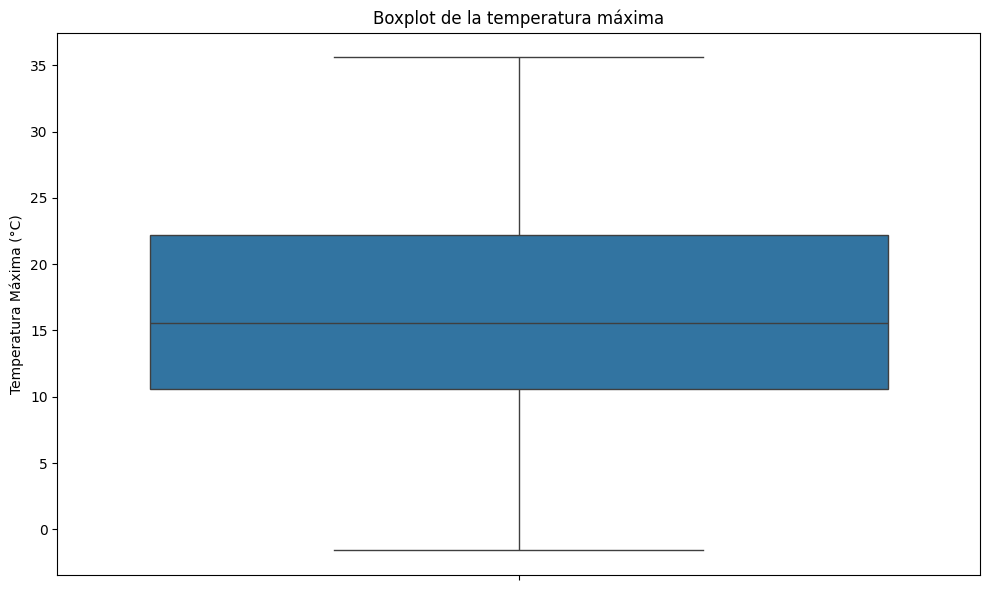

In [25]:
# Gráfica 3: Boxplot para detectar outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos_trabajo, y='temp_max')
plt.title('Boxplot de la temperatura máxima')
plt.ylabel('Temperatura Máxima (°C)')
plt.tight_layout()
plt.show()

Análisis de la Gráfica 3: Boxplot de la temperatura máxima

La gráfica muestra la distribución y dispersión de la temperatura máxima, destacando los valores atípicos (outliers) mediante puntos fuera de los bigotes del boxplot. Se observa que la mayoría de los valores se concentran dentro de un rango intercuartílico definido, aunque existen algunas observaciones extremas que representan temperaturas inusualmente altas o bajas. La presencia de estos outliers sugiere la necesidad de revisar si corresponden a condiciones meteorológicas excepcionales o posibles errores de medición, lo cual es importante para garantizar la calidad y precisión del análisis estadístico.

##### **Análisis Gráfica 4** ⏰ ✌

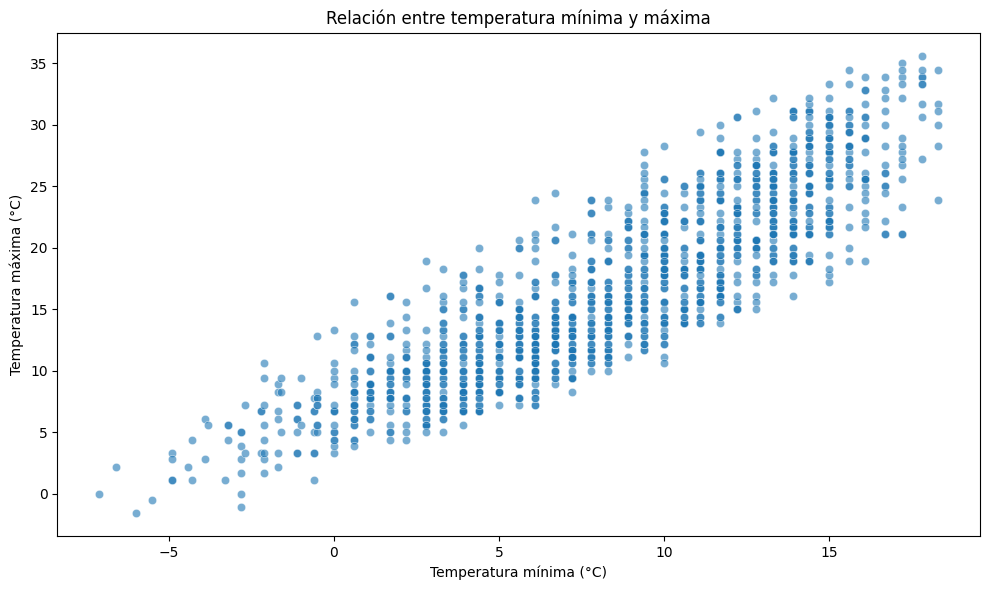

In [17]:
# Gráfica 4: Relación entre dos variables
plt.figure(figsize=(10, 6))
sns.scatterplot(data=datos_trabajo, x='temp_min', y='temp_max', alpha=0.6)
plt.title('Relación entre temperatura mínima y máxima')
plt.xlabel('Temperatura mínima (°C)')
plt.ylabel('Temperatura máxima (°C)')
plt.tight_layout()
plt.show()

Análisis de la Gráfica 4: Relación entre temperatura mínima y máxima

La gráfica muestra la relación entre la temperatura mínima y la temperatura máxima registradas en cada observación. Se aprecia una tendencia lineal positiva, lo que indica que a mayores temperaturas mínimas suelen corresponder mayores temperaturas máximas. Esta relación sugiere una coherencia térmica en los datos, útil para modelar comportamientos climáticos y prever temperaturas extremas a partir de valores mínimos diarios.

##### **Análisis Gráfica 5** ⏰ ✌

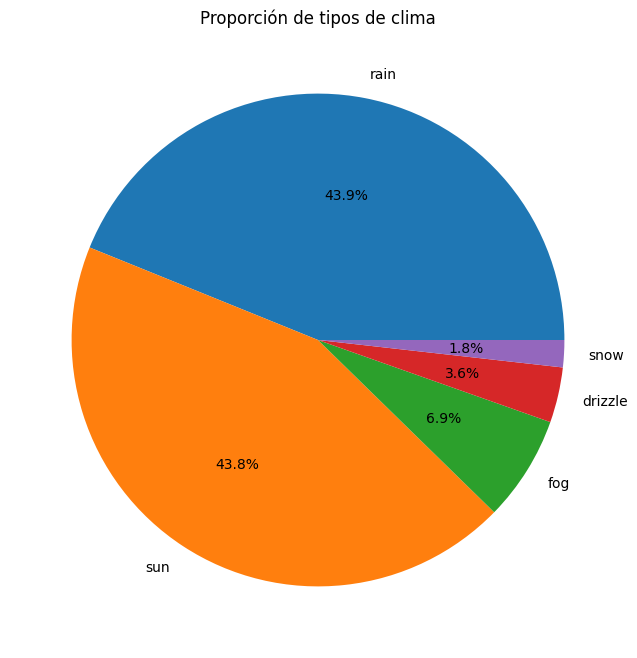

<Figure size 640x480 with 0 Axes>

In [23]:
# Gráfica 5: Gráfica de pastel
plt.figure(figsize=(8, 8))
datos_trabajo['weather'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción de tipos de clima')
plt.ylabel('')
plt.show()
plt.tight_layout()
plt.show()

Análisis de la Gráfica 5: Proporción de tipos de clima

La gráfica de pastel muestra la proporción porcentual de cada tipo de clima dentro del conjunto de datos. Se observa que algunos tipos de clima, como despejado o nublado, ocupan la mayor parte del gráfico, mientras que otros como lluvioso o tormentoso representan una fracción menor. Este patrón indica que el clima predominante durante el periodo analizado es estable, lo cual puede influir significativamente en las variaciones de temperatura y en la planificación de actividades sensibles a las condiciones meteorológicas.

#### **Paso 6: Conversión de variables a Número** ⏰ ✌

In [27]:
# Identificar columnas categóricas
columnas_categoricas = datos_trabajo.select_dtypes(include=['object']).columns
print(f"Columnas categóricas: {list(columnas_categoricas)}")

# Aplicar LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in columnas_categoricas:
    datos_trabajo[col] = le.fit_transform(datos_trabajo[col])

# Verificar conversión
print("\nTipos de datos después de conversión:")
print(datos_trabajo.dtypes)


Columnas categóricas: ['date', 'weather']

Tipos de datos después de conversión:
date               int64
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather            int64
dtype: object


#### **Paso 7: Normalización** ⏰ ✌

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Ver estadísticos antes de normalizar
print("=== ANTES DE NORMALIZACIÓN ===")
print(datos_trabajo.describe().T)

# Aplicar MinMaxScaler (escala 0-1)
scaler = MinMaxScaler()
columnas_numericas = datos_trabajo.select_dtypes(include=['int64', 'float64']).columns
datos_trabajo[columnas_numericas] = scaler.fit_transform(datos_trabajo[columnas_numericas])

# Ver estadísticos después de normalizar
print("\n=== DESPUÉS DE NORMALIZACIÓN ===")
print(datos_trabajo.describe().T)

=== ANTES DE NORMALIZACIÓN ===
                count        mean         std  min    25%    50%     75%  \
date           1461.0  730.000000  421.898685  0.0  365.0  730.0  1095.0   
precipitation  1461.0    3.029432    6.680194  0.0    0.0    0.0     2.8   
temp_max       1461.0   16.439083    7.349758 -1.6   10.6   15.6    22.2   
temp_min       1461.0    8.234771    5.023004 -7.1    4.4    8.3    12.2   
wind           1461.0    3.241136    1.437825  0.4    2.2    3.0     4.0   
weather        1461.0    2.752225    1.191380  0.0    2.0    2.0     4.0   

                  max  
date           1460.0  
precipitation    55.9  
temp_max         35.6  
temp_min         18.3  
wind              9.5  
weather           4.0  

=== DESPUÉS DE NORMALIZACIÓN ===
                count      mean       std  min       25%       50%       75%  \
date           1461.0  0.500000  0.288972  0.0  0.250000  0.500000  0.750000   
precipitation  1461.0  0.054194  0.119503  0.0  0.000000  0.000000  0.0500

Normalizar los datos ayuda a evitar sesgos por diferencias de escala, mejora el rendimiento y la precisión de los modelos, y facilita la interpretación de los resultados.

#### **Paso 8: Correlación** ⏰ ✌

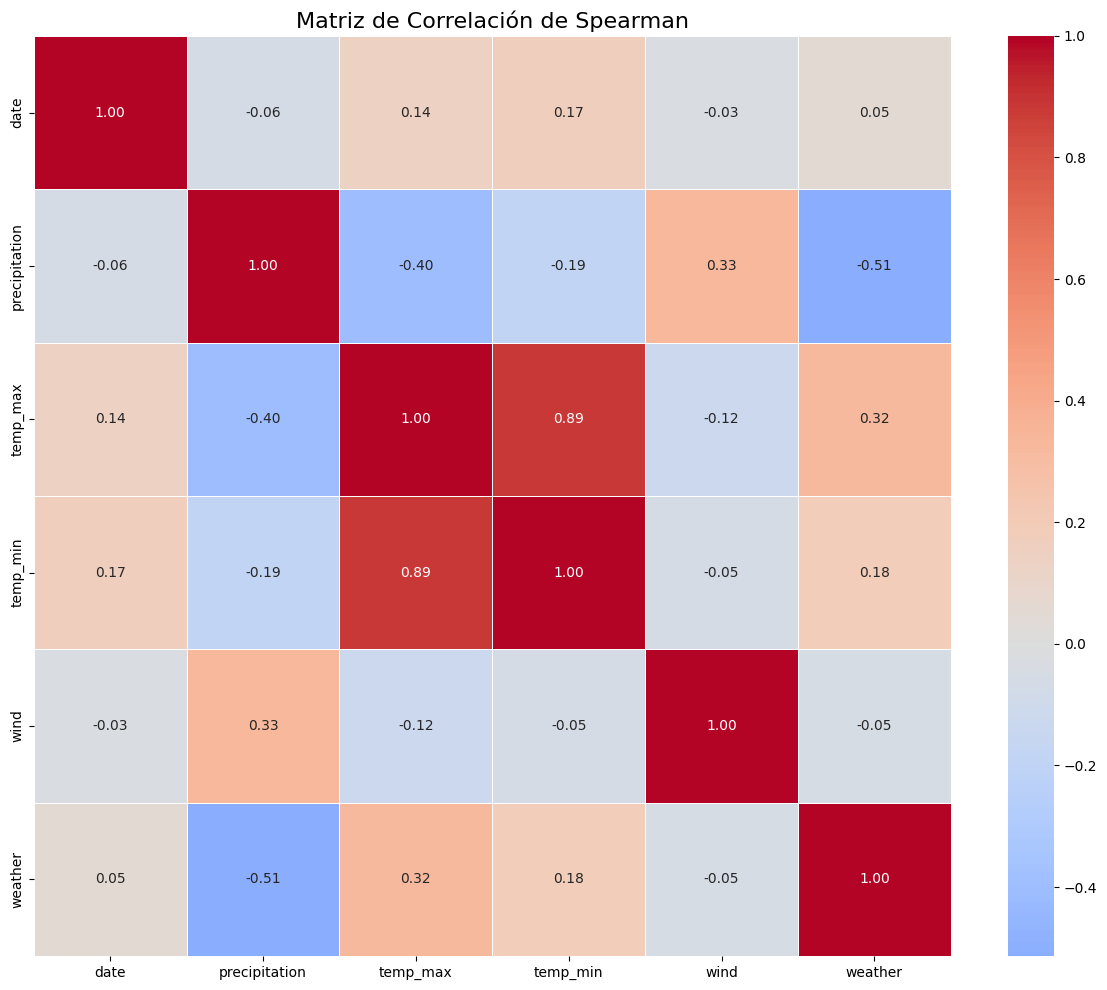


=== CORRELACIONES MÁS FUERTES ===
temp_max <-> temp_min: 0.886
precipitation <-> weather: -0.514


In [31]:
# # Calcular matriz de correlación (Spearman es más robusto)
correlacion = datos_trabajo.corr(method='spearman')

# # Visualizar con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Matriz de Correlación de Spearman', fontsize=16)
plt.tight_layout()
plt.show()

# ---
# # Identificar correlaciones fuertes
print("\n=== CORRELACIONES MÁS FUERTES ===")
# # Obtener pares de correlación (excluyendo diagonal)
correlaciones_fuertes = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        # **Línea corregida con la indentación apropiada**
        if abs(correlacion.iloc[i, j]) > 0.5: # Umbral de 0.5
            correlaciones_fuertes.append((
                correlacion.columns[i],
                correlacion.columns[j],
                correlacion.iloc[i, j]
            ))

# Imprimir las correlaciones fuertes ordenadas por magnitud
for var1, var2, corr in sorted(correlaciones_fuertes, key=lambda x: abs(x[2]), reverse=True):
    print(f"{var1} <-> {var2}: {corr:.3f}")

#### **Paso 9: Test de Normalidad** ⏰ ✌

In [33]:
# Función para test de normalidad
def test_normalidad(dataframe, alpha=0.05):
    print("=== TEST DE SHAPIRO-WILK ===")
    print(f"Nivel de significancia: {alpha}\n")
    for col in dataframe.columns:
        # **Aquí va la indentación necesaria**
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            data = dataframe[col].dropna()
            if len(data) >= 3:
                stat, p_value = shapiro(data)
                resultado = "NORMAL" if p_value > alpha else "NO NORMAL"
                print(f"{col}:")
                print(f" Estadístico W: {stat:.4f}")
                print(f" P-valor: {p_value:.4f}")
                print(f" Conclusión: {resultado}\n")
# Aplicar test
# test_normalidad(datos_trabajo)

#### **Paso 10: Pregunta de Investigación** ⏰ ✌

¿Es posible predecir la edad de los estudiantes con base en las preguntas de la encuesta y con que eficiencia?

#### **Paso 11: Ejercicio de Regresión - Predicción** ⏰ ✌


===== RESULTADOS DEL MODELO =====
Coeficiente de determinación R²: 0.8979
Intercepto: 5.171661797187693
Coeficientes: [ 2.16470712 -3.11993919  4.04572978]

Coeficientes del modelo:
  Variable  Coeficiente
0       X1     2.164707
1       X2    -3.119939
2       X3     4.045730

Importancia de las variables:
  Variable  Coeficiente  Importancia
2       X3     4.045730     4.045730
1       X2    -3.119939     3.119939
0       X1     2.164707     2.164707


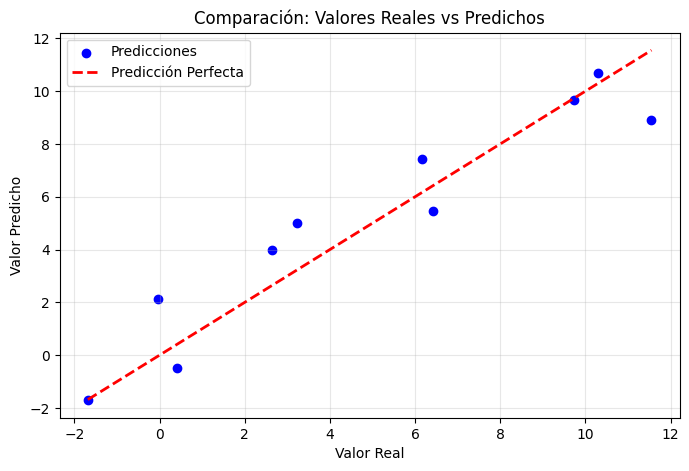

In [37]:
# 1. Crear variables predictoras (X) y variable objetivo (y)
def crear_variables_predictoras():
    np.random.seed(42)  # Semilla para reproducibilidad

    # Generar datos simulados
    X = np.random.randn(50, 3)  # 50 muestras, 3 variables predictoras
    y_target = 5 + 2*X[:, 0] - 3*X[:, 1] + 4*X[:, 2] + np.random.normal(0, 1.5, 50)

    # Convertir a DataFrame para mayor claridad
    datos_trabajo = pd.DataFrame(X, columns=['X1', 'X2', 'X3'])
    datos_trabajo['y'] = y_target

    return datos_trabajo, X, y_target

# Llamar a la función para generar datos
datos_trabajo, X, y_target = crear_variables_predictoras()

# ---------------------------------------------------------
# 2. Dividir datos en entrenamiento y prueba
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Crear y entrenar modelo
# ---------------------------------------------------------
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Realizar predicciones
# ---------------------------------------------------------
y_pred = modelo.predict(X_test)

# ---------------------------------------------------------
# 5. Evaluar el modelo
# ---------------------------------------------------------
r2 = r2_score(y_test, y_pred)
print("\n===== RESULTADOS DEL MODELO =====")
print(f"Coeficiente de determinación R²: {r2:.4f}")
print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)

# Mostrar qué variable corresponde a cada coeficiente
coeficientes = pd.DataFrame({
    'Variable': ['X1', 'X2', 'X3'],
    'Coeficiente': modelo.coef_
})
print("\nCoeficientes del modelo:")
print(coeficientes)

# ---------------------------------------------------------
# 6. Importancia de las variables (por valor absoluto)
# ---------------------------------------------------------
coeficientes['Importancia'] = coeficientes['Coeficiente'].abs()
coef_importancia = coeficientes.sort_values(by='Importancia', ascending=False)

print("\nImportancia de las variables:")
print(coef_importancia)

# ---------------------------------------------------------
# 7. Visualización
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

plt.title('Comparación: Valores Reales vs Predichos')
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()